In [1]:
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from tensorflow.keras.utils import to_categorical, load_img
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
TRAIN_DIR = "../data/FER2013/train"
TEST_DIR = "../data/FER2013/test"

print("Train directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))
print("Dataset folders:", os.listdir("../data/FER2013"))

Train directory exists: True
Test directory exists: True
Dataset folders: ['test', 'train']


In [3]:
def createdataframe(directory):
    image_paths = []
    labels = []

    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)

        if os.path.isdir(label_path):
            for imagename in os.listdir(label_path):
                image_path = os.path.join(label_path, imagename)
                image_paths.append(image_path)
                labels.append(label)

            print(label, "completed")

    return image_paths, labels

In [4]:
# Create train dataframe
train = pd.DataFrame()
train["image"], train["label"] = createdataframe(TRAIN_DIR)

# Create test dataframe
test = pd.DataFrame()
test["image"], test["label"] = createdataframe(TEST_DIR)

print("Train dataframe:")
print(train)

print("\nTest dataframe:")
print(test)

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed
angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed
Train dataframe:
                                         image     label
0            ../data/FER2013/train\angry\0.jpg     angry
1            ../data/FER2013/train\angry\1.jpg     angry
2           ../data/FER2013/train\angry\10.jpg     angry
3        ../data/FER2013/train\angry\10002.jpg     angry
4        ../data/FER2013/train\angry\10016.jpg     angry
...                                        ...       ...
28816  ../data/FER2013/train\surprise\9969.jpg  surprise
28817  ../data/FER2013/train\surprise\9985.jpg  surprise
28818  ../data/FER2013/train\surprise\9990.jpg  surprise
28819  ../data/FER2013/train\surprise\9992.jpg  surprise
28820  ../data/FER2013/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]

Test dataframe:
                        

Image path: ../data/FER2013/train\angry\0.jpg
Label: angry


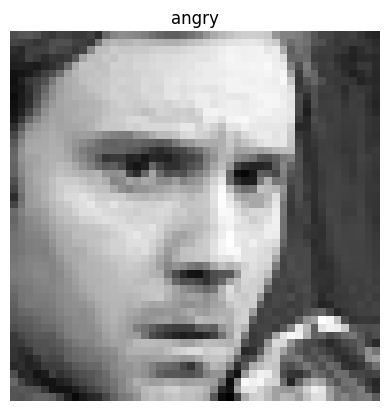

In [8]:
# Show one image from train dataframe
index = 0
img_path = train["image"][index]
label = train["label"][index]

print("Image path:", img_path)
print("Label:", label)

img = load_img(img_path, color_mode="grayscale", target_size=(48, 48))
plt.imshow(img, cmap="gray")
plt.title(label)
plt.axis("off")
plt.show()

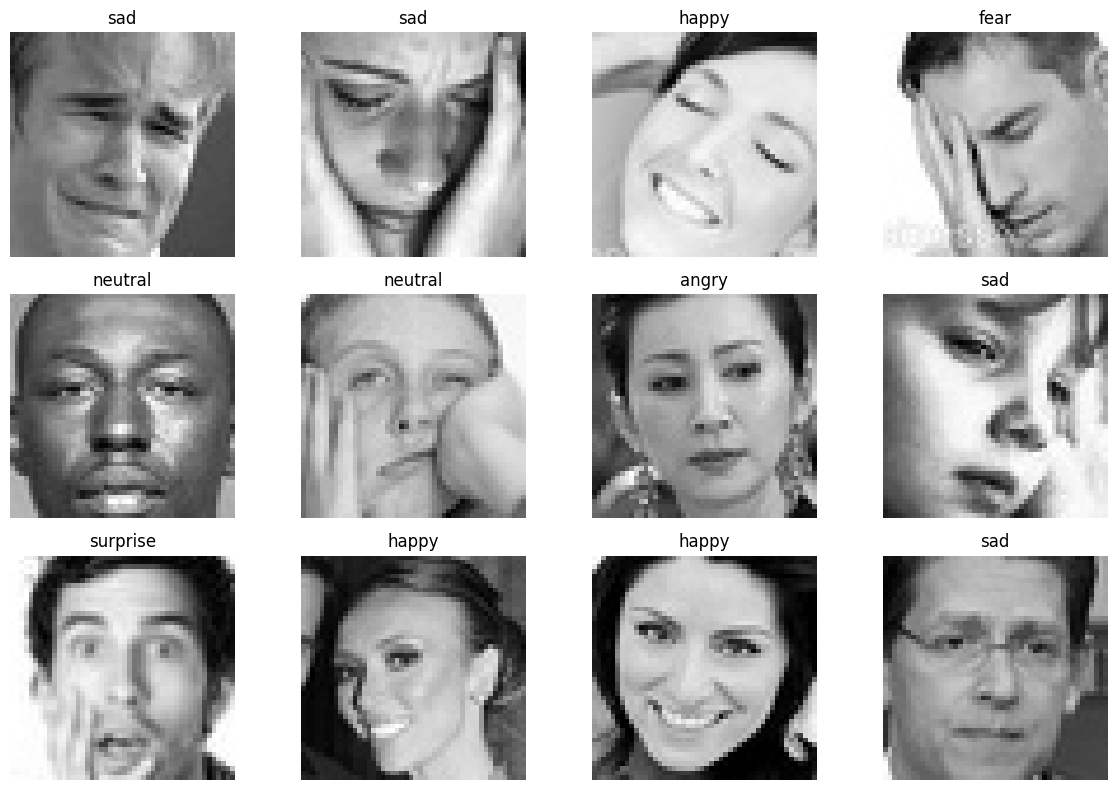

In [9]:
# Show multiple random images from train dataframe
sample_data = train.sample(12, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 8))

for i in range(12):
    img_path = sample_data["image"][i]
    label = sample_data["label"][i]

    img = load_img(img_path, color_mode="grayscale", target_size=(48, 48))

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale", target_size=(48, 48))
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)

    return features


train_features = extract_features(train["image"])
test_features = extract_features(test["image"])

print("Train features shape:", train_features.shape)
print("Test features shape:", test_features.shape)

  0%|          | 0/28821 [00:00<?, ?it/s]

  0%|          | 0/7066 [00:00<?, ?it/s]

Train features shape: (28821, 48, 48, 1)
Test features shape: (7066, 48, 48, 1)


In [11]:
x_train = train_features / 255.0
x_test = test_features / 255.0

print("x_train min/max:", x_train.min(), x_train.max())
print("x_test min/max:", x_test.min(), x_test.max())

x_train min/max: 0.0 1.0
x_test min/max: 0.0 1.0


In [12]:
le = LabelEncoder()
le.fit(train["label"])

y_train = le.transform(train["label"])
y_test = le.transform(test["label"])

y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

emotion_labels = list(le.classes_)

print("Emotion labels:", emotion_labels)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
y_train shape: (28821, 7)
y_test shape: (7066, 7)


In [13]:
model = Sequential()

model.add(Input(shape=(48, 48, 1)))

model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.30))

model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.35))

model.add(Conv2D(512, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.40))

model.add(Flatten())

model.add(Dense(512, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.50))

model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.40))

model.add(Dense(7, activation="softmax"))

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,826,055 (18.41 MB)

 Trainable params: 4,821,703 (18.39 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [18]:
os.makedirs("../models/FER2013", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        "../models/FER2013/best_fer2013_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [19]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

Epoch 1/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.1652 - loss: 2.7697
Epoch 1: val_accuracy improved from None to 0.14053, saving model to ../models/FER2013/best_fer2013_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 430s 940ms/step - accuracy: 0.1822 - loss: 2.6192 - val_accuracy: 0.1405 - val_loss: 2.0200 - learning_rate: 1.0000e-04
Epoch 2/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2151 - loss: 2.3286
Epoch 2: val_accuracy improved from 0.14053 to 0.28205, saving model to ../models/FER2013/best_fer2013_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 1208s 3s/step - accuracy: 0.2270 - loss: 2.2628 - val_accuracy: 0.2821 - val_loss: 1.8376 - learning_rate: 1.0000e-04
Epoch 3/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2648 - loss: 2.0953
Epoch 3: val_accuracy improved from 0.28205 to 0.32536, saving model to ../models/FER2013/best_fer2013_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 1163s 3s/step - accuracy: 0.2698 - loss: 2.0592 - val_accuracy: 0.3254 -

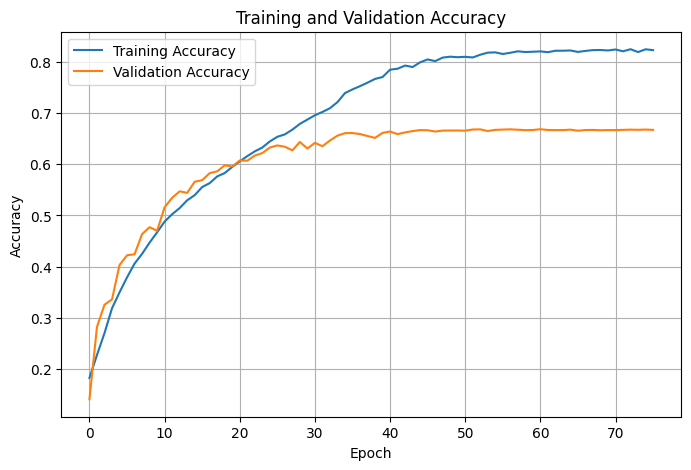

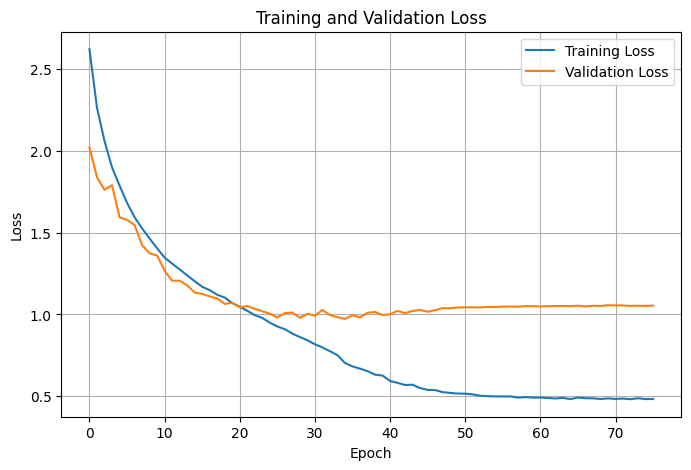

In [20]:
# Training and validation accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("../img/fer2013_training_accuracy_graph.png", dpi=300)
plt.show()

# Training and validation loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("../img/fer2013_training_loss_graph.png", dpi=300)
plt.show()

In [21]:
# Predict test data
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

print("Overall Metrics")
print(metrics_df)

metrics_df.to_csv("../results/fer2013_overall_metrics.csv", index=False)

221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step
Overall Metrics
      Metric     Value
0   Accuracy  0.668554
1  Precision  0.679433
2     Recall  0.668554
3   F1-score  0.669099


In [22]:
report = classification_report(
    y_true,
    y_pred,
    target_names=emotion_labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("Classification Report")
print(report_df)

report_df.to_csv("../results/fer2013_classification_report.csv")

Classification Report
              precision    recall  f1-score      support
angry          0.694529  0.476042  0.564895   960.000000
disgust        0.700000  0.630631  0.663507   111.000000
fear           0.540710  0.508841  0.524291  1018.000000
happy          0.850722  0.871233  0.860855  1825.000000
neutral        0.581949  0.662829  0.619762  1216.000000
sad            0.492210  0.610184  0.544884  1139.000000
surprise       0.859649  0.737767  0.794058   797.000000
accuracy       0.668554  0.668554  0.668554     0.668554
macro avg      0.674253  0.642504  0.653179  7066.000000
weighted avg   0.679433  0.668554  0.669099  7066.000000


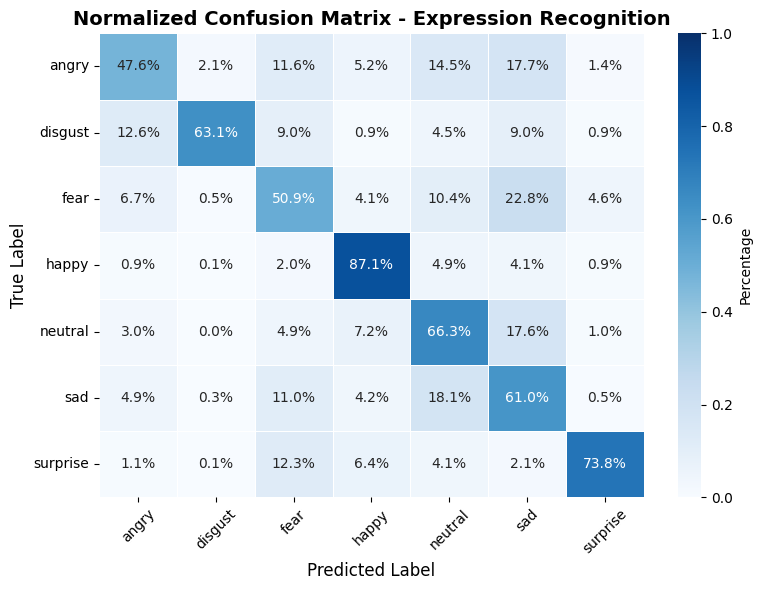

In [35]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, normalize='true')

# Save as CSV for Streamlit app
cm_df = pd.DataFrame(cm, index=emotion_labels, columns=emotion_labels)
cm_df.to_csv("../results/fer2013_confusion_matrix_normalized.csv")


# Plot with Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.1%',
    cmap='Blues',
    xticklabels=emotion_labels,
    yticklabels=emotion_labels,
    linewidths=0.5,
    linecolor='white',
    vmin=0, 
    vmax=1,
    cbar_kws={'label': 'Percentage'}
)
plt.title('Normalized Confusion Matrix - Expression Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Save high-res image
plt.savefig("../img/fer2013_confusion_matrix_normalized.png", dpi=300, bbox_inches='tight')

plt.show()

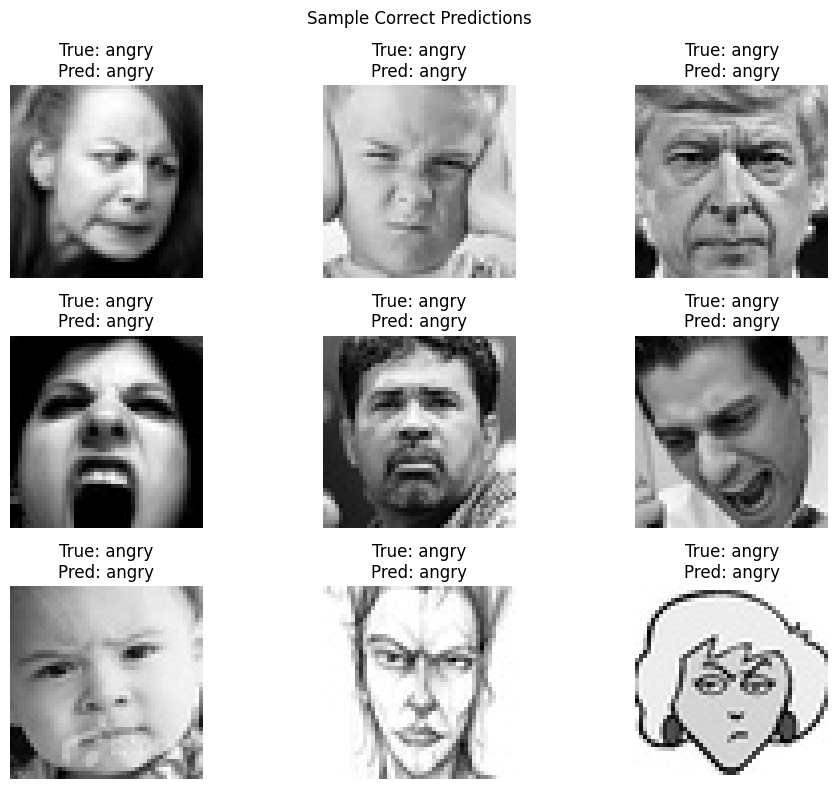

In [24]:
correct_indices = np.where(y_true == y_pred)[0]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(correct_indices[:9]):
    img = x_test[idx].reshape(48, 48)

    true_label = emotion_labels[y_true[idx]]
    pred_label = emotion_labels[y_pred[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Sample Correct Predictions")
plt.tight_layout()
plt.savefig("../results/fer2013_sample_correct_predictions.png", dpi=300)
plt.show()

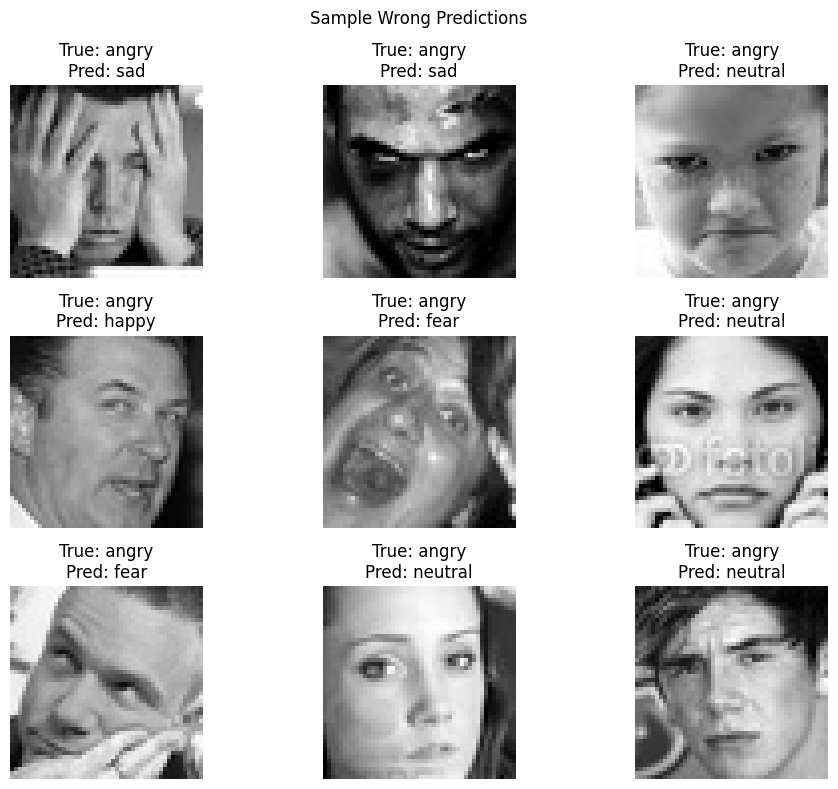

In [25]:
wrong_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(wrong_indices[:9]):
    img = x_test[idx].reshape(48, 48)

    true_label = emotion_labels[y_true[idx]]
    pred_label = emotion_labels[y_pred[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Sample Wrong Predictions")
plt.tight_layout()
plt.savefig("../results/fer2013_sample_wrong_predictions.png", dpi=300)
plt.show()

In [27]:
# Save final model architecture and weights
model_json = model.to_json()

with open("../models/FER2013/emotiondetector.json", "w") as json_file:
    json_file.write(model_json)

model.save("../models/FER2013/emotiondetector.h5")
model.save("../models/FER2013/final_fer2013_model.keras")

print("Models saved successfully.")
print("Best model saved at: models/FER2013/best_fer2013_model.keras")
print("Final model saved at: models/FER2013/final_fer2013_model.keras")
print("JSON + H5 model saved at: models/FER2013/emotiondetector.json and models/FER2013/emotiondetector.h5")

Models saved successfully.
Best model saved at: models/FER2013/best_fer2013_model.keras
Final model saved at: models/FER2013/final_fer2013_model.keras
JSON + H5 model saved at: models/FER2013/emotiondetector.json and models/FER2013/emotiondetector.h5


In [29]:
# Load best trained model
model = load_model("../models/FER2013/best_fer2013_model.keras")

# Use same labels from LabelEncoder
emotion_labels = list(le.classes_)

print("Model loaded successfully")
print("Emotion labels:", emotion_labels)


def get_sentiment(emotion):
    """Convert predicted emotion into a simple sentiment category."""

    if emotion in ["happy", "surprise"]:
        sentiment = "Positive"
        text = "The detected facial expression suggests a positive emotional state."

    elif emotion in ["angry", "disgust", "fear", "sad"]:
        sentiment = "Negative"
        text = "The detected facial expression suggests a negative emotional state."

    elif emotion == "neutral":
        sentiment = "Neutral"
        text = "The detected facial expression suggests a neutral emotional state."

    else:
        sentiment = "Unknown"
        text = "Sentiment could not be determined."

    return sentiment, text


def preprocess_image(image_path):
    """Load one image, convert it to grayscale, resize it to 48x48, normalize it, and reshape it for CNN input."""

    img = load_img(image_path, color_mode="grayscale", target_size=(48, 48))
    img = np.array(img)
    img = img.reshape(1, 48, 48, 1)
    img = img / 255.0

    return img


def predict_single_image(image_path, original_label):
    """Predict emotion and sentiment for one image."""

    print("Original image is of:", original_label)

    img = preprocess_image(image_path)

    pred = model.predict(img)
    pred_index = np.argmax(pred)

    pred_label = emotion_labels[pred_index]
    confidence = np.max(pred) * 100

    sentiment, sentiment_text = get_sentiment(pred_label)

    print("Model prediction is:", pred_label)
    print("Confidence:", round(confidence, 2), "%")
    print("Sentiment:", sentiment)
    print("Sentiment Analysis:", sentiment_text)

    plt.imshow(img.reshape(48, 48), cmap="gray")
    plt.title(
        f"True: {original_label}\nPredicted: {pred_label} ({confidence:.2f}%)\nSentiment: {sentiment}"
    )
    plt.axis("off")
    plt.show()

Model loaded successfully
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Original image is of: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
Model prediction is: sad
Confidence: 85.25 %
Sentiment: Negative
Sentiment Analysis: The detected facial expression suggests a negative emotional state.


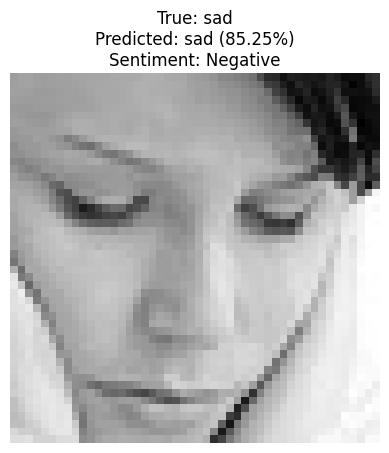

Original image is of: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Model prediction is: fear
Confidence: 64.15 %
Sentiment: Negative
Sentiment Analysis: The detected facial expression suggests a negative emotional state.


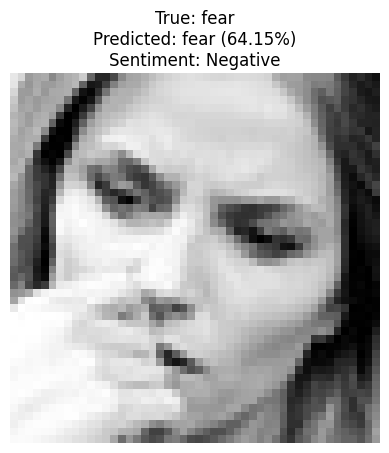

Original image is of: disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Model prediction is: disgust
Confidence: 96.59 %
Sentiment: Negative
Sentiment Analysis: The detected facial expression suggests a negative emotional state.


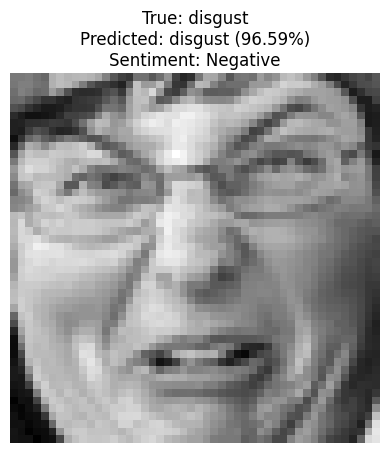

Original image is of: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Model prediction is: happy
Confidence: 99.85 %
Sentiment: Positive
Sentiment Analysis: The detected facial expression suggests a positive emotional state.


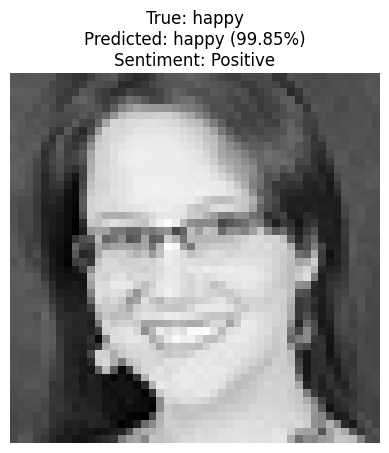

Original image is of: surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Model prediction is: surprise
Confidence: 92.41 %
Sentiment: Positive
Sentiment Analysis: The detected facial expression suggests a positive emotional state.


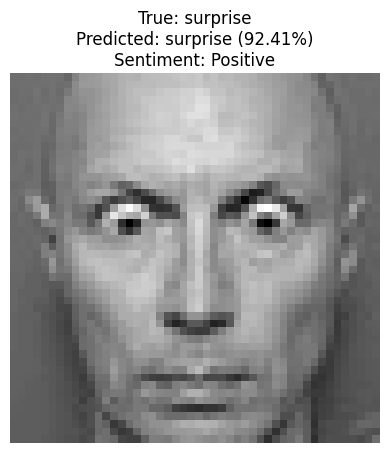

In [30]:
predict_single_image(
    "../data/FER2013/train/sad/42.jpg",
    "sad"
)

predict_single_image(
    "../data/FER2013/train/fear/2.jpg",
    "fear"
)

predict_single_image(
    "../data/FER2013/train/disgust/299.jpg",
    "disgust"
)

predict_single_image(
    "../data/FER2013/train/happy/7.jpg",
    "happy"
)

predict_single_image(
    "../data/FER2013/train/surprise/15.jpg",
    "surprise"
)